In [6]:
# Environment Setup and Data Loading
# Set up the Python environment and create a unified analytical DataFrame

In [1]:
# a) Import libraries: pandas, numpy, matplotlib, seaborn — with correct aliases (pd, np, plt, sns)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# b) Create three DataFrames (customers, products, sales) from the dataset provided above
customers = pd.DataFrame({
'CustomerID':['C001','C002','C003','C004','C005','C006'],
'CustomerName':['Rahul Sharma','Neha Verma','Arjun Mehta','Kavita Rao','Aman Gupta','Pooja Nair'],
'Gender':['Male','Female','Male','Female','Male','Female'],
'City':['Mumbai','Delhi','Pune','Bangalore','Mumbai','Kochi'],
'JoinDate':['2022-01-15','2021-11-20','2022-06-05','2023-02-10','2021-09-18','2022-03-12']
})

In [3]:
# Products
products = pd.DataFrame({
'ProductID':['P001','P002','P003','P004','P005','P006'],
'ProductName':['Laptop','Headphones','Office Chair','Desk Lamp','Smartphone','Bookshelf'],
'Category':['Electronics','Electronics','Furniture','Furniture','Electronics','Furniture'],
'Price':[55000,3000,12000,2500,32000,18000]
})


In [4]:
# Sales
sales = pd.DataFrame({
'SaleID':['S001','S002','S003','S004','S005','S006'],
'SaleDate':['2023-01-10','2023-01-12','2023-02-05','2023-02-20','2023-03-02','2023-03-15'],
'CustomerID':['C001','C002','C001','C004','C005','C006'],
'ProductID':['P001','P003','P002','P004','P005','P006'],
'Quantity':[1,2,3,2,1,1],
'Region':['West','North','West','South','West','South']
})

In [5]:
# c) Merge all three DataFrames and compute df['Revenue'] = df['Quantity'] * df['Price']
df = sales.merge(customers,on='CustomerID').merge(products,on='ProductID')

In [7]:
# Revenue
df['Revenue'] = df['Quantity'] * df['Price']
df.head()

,SaleID,SaleDate,CustomerID,ProductID,Quantity,Region,CustomerName,Gender,City,JoinDate,ProductName,Category,Price,Revenue
0,S001,2023-01-10,C001,P001,1,West,Rahul Sharma,Male,Mumbai,2022-01-15,Laptop,Electronics,55000,55000
1,S002,2023-01-12,C002,P003,2,North,Neha Verma,Female,Delhi,2021-11-20,Office Chair,Furniture,12000,24000
2,S003,2023-02-05,C001,P002,3,West,Rahul Sharma,Male,Mumbai,2022-01-15,Headphones,Electronics,3000,9000
3,S004,2023-02-20,C004,P004,2,South,Kavita Rao,Female,Bangalore,2023-02-10,Desk Lamp,Furniture,2500,5000
4,S005,2023-03-02,C005,P005,1,West,Aman Gupta,Male,Mumbai,2021-09-18,Smartphone,Electronics,32000,32000


In [9]:
# Exploratory Data Analysis
# Perform the analyses below using Pandas. Show output cells in your Jupyter Notebook
# a) Dataset overview — run .shape, .dtypes, .describe(), .isnull().sum() and interpret results
df.shape

(6, 14)

In [10]:
df.dtypes

,0
SaleID,object
SaleDate,object
CustomerID,object
ProductID,object
Quantity,int64
Region,object
CustomerName,object
Gender,object
City,object
JoinDate,object


In [11]:
df.describe()

,Quantity,Price,Revenue
count,6.000000,6.000000,6.000000
mean,1.666667,20416.666667,23833.333333
std,0.816497,20155.437645,18148.461826
min,1.000000,2500.000000,5000.000000
25%,1.000000,5250.000000,11250.000000
50%,1.500000,15000.000000,21000.000000
75%,2.000000,28500.000000,30000.000000
max,3.000000,55000.000000,55000.000000


In [12]:
df.isnull().sum()

,0
SaleID,0
SaleDate,0
CustomerID,0
ProductID,0
Quantity,0
Region,0
CustomerName,0
Gender,0
City,0
JoinDate,0


In [13]:
# b) Verify the Revenue column using
# df[['ProductName','Quantity','Price','Revenue']].head()
df[['ProductName','Quantity','Price','Revenue']].head()


,ProductName,Quantity,Price,Revenue
0,Laptop,1,55000,55000
1,Office Chair,2,12000,24000
2,Headphones,3,3000,9000
3,Desk Lamp,2,2500,5000
4,Smartphone,1,32000,32000


In [14]:
# c) Group-by analysis using groupby() + sum(): 1.5
# Region-wise total Revenue
df.groupby('Region')['Revenue'].sum()

,Revenue
Region,
North,24000
South,23000
West,96000


In [15]:
# Category-wise total Revenue
df.groupby('Category')['Revenue'].sum()

,Revenue
Category,
Electronics,96000
Furniture,47000


In [16]:
# d) Customer frequency using value_counts() on CustomerID — identify repeat buyers
df['CustomerID'].value_counts()

,count
CustomerID,
C001,2
C002,1
C004,1
C005,1
C006,1


In [20]:
# e) Monthly trend — convert SaleDate to datetime, extract month using dt.month or dt.to_period('M')
df['SaleDate'] = pd.to_datetime(df['SaleDate'])
df['Month'] = df['SaleDate'].dt.month
df.groupby('Month')['Revenue'].sum()

,Revenue
Month,
1,79000
2,14000
3,50000


In [21]:
# f) Top 3 customers by Revenue using sort_values(ascending=False).head(3)
df.groupby('CustomerName')['Revenue'].sum().sort_values(ascending=False).head(3)

,Revenue
CustomerName,
Rahul Sharma,64000
Aman Gupta,32000
Neha Verma,24000


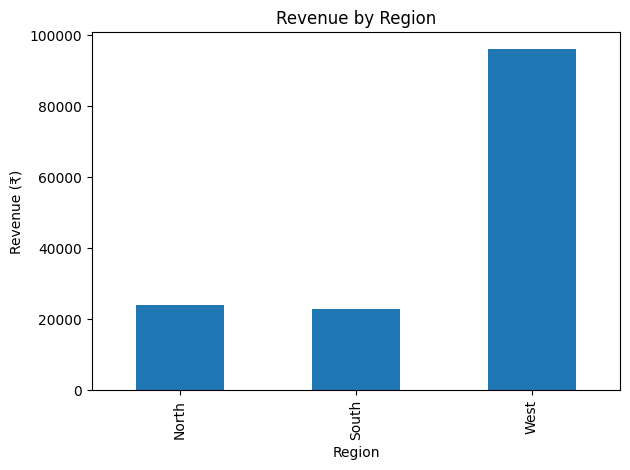

In [22]:
# Data Visualisation
# Create the three charts below. Each chart MUST include: title, x-label, y-label, and tight_layout().
# a) Revenue by Region
region_rev = df.groupby('Region')['Revenue'].sum()

region_rev.plot(kind='bar')
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig('region_revenue.png',dpi=150)
plt.show()


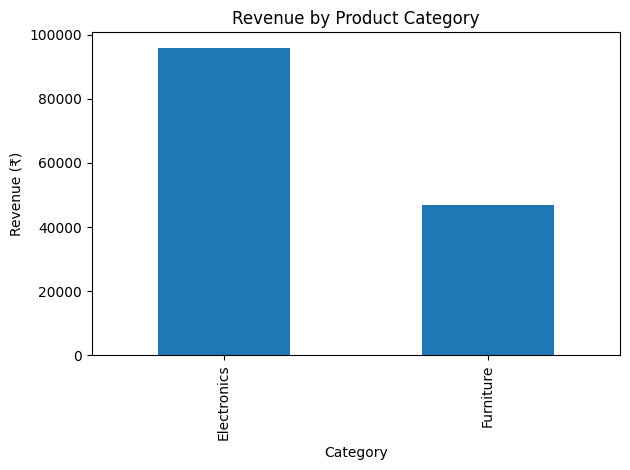

In [23]:
# b) Revenue by Product Category
cat_rev = df.groupby('Category')['Revenue'].sum()

cat_rev.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig('category_revenue.png',dpi=150)
plt.show()

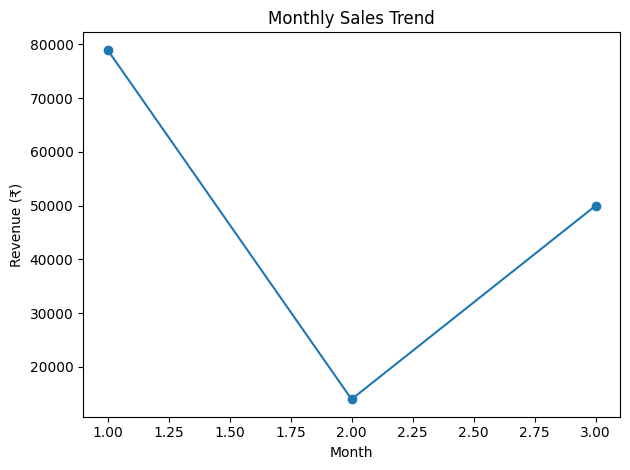

In [24]:
# c) Monthly Sales Trend
month_rev = df.groupby('Month')['Revenue'].sum()

month_rev.plot(kind='line',marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.tight_layout()
plt.savefig('monthly_trend.png',dpi=150)
plt.show()